# GW1 Prediction Explainability Notebook

This notebook explains how the system arrived at the GW1 squad in two layers:
1. Forecast layer: how player point estimates are generated.
2. Optimization layer: how those estimates are converted into a legal 15-man squad and XI.

Important context:
- The current GW1 live candidate file was built from FPL API signals with a lightweight expected-points proxy.
- So this notebook explains optimizer selection directly from that candidate file, and also shows model-level feature influence using the forecasting module on the project sample dataset.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path('..').resolve()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from fpl_ai_agent.config import load_validated_config
from fpl_ai_agent.contracts import OptimiserInputContract
from fpl_ai_agent.optimisation.problem import (
    OptimisationSettings,
    TransferContext,
    compute_discounted_risk,
    compute_discounted_value,
    optimize_squad,
)
from fpl_ai_agent.optimisation.lineup import LineupSettings, optimize_lineup

cfg = load_validated_config(ROOT / 'configs' / 'base.yaml')
live_path = ROOT / 'data' / 'live' / 'optimiser_candidates_gw1.json'
rec_path = ROOT / 'artifacts' / 'recommendations' / 'gw1_optimal_squad_live.json'

rows = json.loads(live_path.read_text(encoding='utf-8'))
candidates = [OptimiserInputContract(**row) for row in rows]
recommendation = json.loads(rec_path.read_text(encoding='utf-8'))

len(candidates), recommendation['total_cost']

(270, 100.0)

## Step 1: Recompute GW1 optimization and decompose objective
This reproduces the selected squad and calculates each selected player's contribution to the objective.

In [2]:
# Latest saved recommendation (after most recent optimizer run).
squad_df = pd.DataFrame(recommendation['squad']).sort_values(['position', 'player_name']).reset_index(drop=True)
starters_df = pd.DataFrame(recommendation['starters']).reset_index(drop=True)
bench_df = pd.DataFrame(recommendation['bench_order']).reset_index(drop=True)

print('GW:', recommendation['gameweek'])
print('Chip:', recommendation['chip_used'])
print('Captain:', recommendation['captain'])
print('Vice-captain:', recommendation['vice_captain'])
print('Total cost:', recommendation['total_cost'])

display(squad_df)
display(starters_df)
display(bench_df)

GW: 1
Chip: wildcard
Captain: Gabriel dos Santos Magalhães
Vice-captain: Virgil van Dijk
Total cost: 100.0


,player_name,position,team,cost
0,Gabriel dos Santos Magalhães,DEF,ARS,8.0
1,Matheus Nunes,DEF,MCI,6.0
2,Maxence Lacroix,DEF,CRY,6.0
3,Nico O'Reilly,DEF,MCI,6.5
4,Virgil van Dijk,DEF,LIV,6.5
5,Enes Ünal,FWD,BOU,5.5
6,Francisco Evanilson de Lima Barbosa,FWD,BOU,6.0
7,Jørgen Strand Larsen,FWD,CRY,6.0
8,Alisson Becker,GK,LIV,5.5
9,David Raya Martín,GK,ARS,6.0


,player_name,position,team,cost
0,David Raya Martín,GK,ARS,6.0
1,Gabriel dos Santos Magalhães,DEF,ARS,8.0
2,Virgil van Dijk,DEF,LIV,6.5
3,Nico O'Reilly,DEF,MCI,6.5
4,Maxence Lacroix,DEF,CRY,6.0
5,Matheus Nunes,DEF,MCI,6.0
6,Bryan Mbeumo,MID,MUN,8.0
7,Matheus Santos Carneiro da Cunha,MID,MUN,8.0
8,Morgan Gibbs-White,MID,NFO,8.0
9,Enzo Fernández,MID,CHE,7.0


,player_name,position,team,cost
0,Enes Ünal,FWD,BOU,5.5
1,Jørgen Strand Larsen,FWD,CRY,6.0
2,Marcus Rashford,MID,MUN,7.0
3,Alisson Becker,GK,LIV,5.5


In [2]:
import inspect

pos_score_cfg = getattr(cfg.optimisation, 'position_score_weights', None)
pos_risk_cfg = getattr(cfg.optimisation, 'position_risk_weights', None)

settings_kwargs = {
    'horizon_weeks': cfg.optimisation.horizon_weeks,
    'discount_factor': cfg.backtesting.discount_factor,
    'transfer_penalty': cfg.optimisation.transfer_penalty,
    'risk_aversion': cfg.optimisation.risk_aversion,
    'budget': cfg.optimisation.budget,
    'max_from_team': cfg.optimisation.max_from_team,
}
params = inspect.signature(OptimisationSettings).parameters
if 'position_score_weights' in params:
    settings_kwargs['position_score_weights'] = pos_score_cfg
if 'position_risk_weights' in params:
    settings_kwargs['position_risk_weights'] = pos_risk_cfg

settings = OptimisationSettings(**settings_kwargs)

context = TransferContext(
    current_squad_ids=set(),
    free_transfers=1,
    wildcard_available=True,
    free_hit_available=True,
    bench_boost_available=True,
    wildcard_bonus=cfg.optimisation.wildcard_bonus,
    free_hit_bonus=cfg.optimisation.free_hit_bonus,
    bench_boost_bonus=cfg.optimisation.bench_boost_bonus,
 )

squad = optimize_squad(candidates, settings=settings, transfer_context=context)
selected_ids = set(squad.selected_player_ids)

if hasattr(settings, 'normalized_position_score_weights'):
    pos_score_weights = settings.normalized_position_score_weights()
else:
    pos_score_weights = {'GK': 1.0, 'DEF': 1.0, 'MID': 1.0, 'FWD': 1.0}

if hasattr(settings, 'normalized_position_risk_weights'):
    pos_risk_weights = settings.normalized_position_risk_weights()
else:
    pos_risk_weights = {'GK': 1.0, 'DEF': 1.0, 'MID': 1.0, 'FWD': 1.0}

records = []
for c in candidates:
    exp_val = (
        compute_discounted_value(c.expected_points_horizon[:settings.horizon_weeks], settings.discount_factor)
        * c.availability_probability
        * pos_score_weights.get(c.position, 1.0)
    )
    risk_val = (
        compute_discounted_risk(c.uncertainty_horizon[:settings.horizon_weeks], settings.discount_factor)
        * pos_risk_weights.get(c.position, 1.0)
    )
    score = exp_val - settings.risk_aversion * risk_val
    records.append({
        'player_id': c.player_id,
        'player_name': c.player_name,
        'team': c.team,
        'position': c.position,
        'cost': c.cost,
        'selected': c.player_id in selected_ids,
        'exp_component': exp_val,
        'risk_component': risk_val,
        'net_score': score,
    })

score_df = pd.DataFrame(records)
selected_df = score_df[score_df['selected']].sort_values('net_score', ascending=False).reset_index(drop=True)
selected_df[['player_name', 'position', 'team', 'cost', 'exp_component', 'risk_component', 'net_score']].head(15)

,player_name,position,team,cost,exp_component,risk_component,net_score
0,Gabriel dos Santos Magalhães,DEF,ARS,8.0,11.413504,3.598099,10.873789
1,David Raya Martín,GK,ARS,6.0,11.413504,3.957909,10.819818
2,Alisson Becker,GK,LIV,5.5,9.416141,3.957909,8.822454
3,Virgil van Dijk,DEF,LIV,6.5,8.845466,3.598099,8.305751
4,Nico O'Reilly,DEF,MCI,6.5,8.845466,3.598099,8.305751
5,Bryan Mbeumo,MID,MUN,8.0,8.229136,3.598099,7.689422
6,Morgan Gibbs-White,MID,NFO,8.0,8.229136,3.598099,7.689422
7,Maxence Lacroix,DEF,CRY,6.0,7.989453,3.598099,7.449738
8,Matheus Nunes,DEF,MCI,6.0,7.989453,3.598099,7.449738
9,Enzo Fernández,MID,CHE,7.0,7.347443,3.598099,6.807728


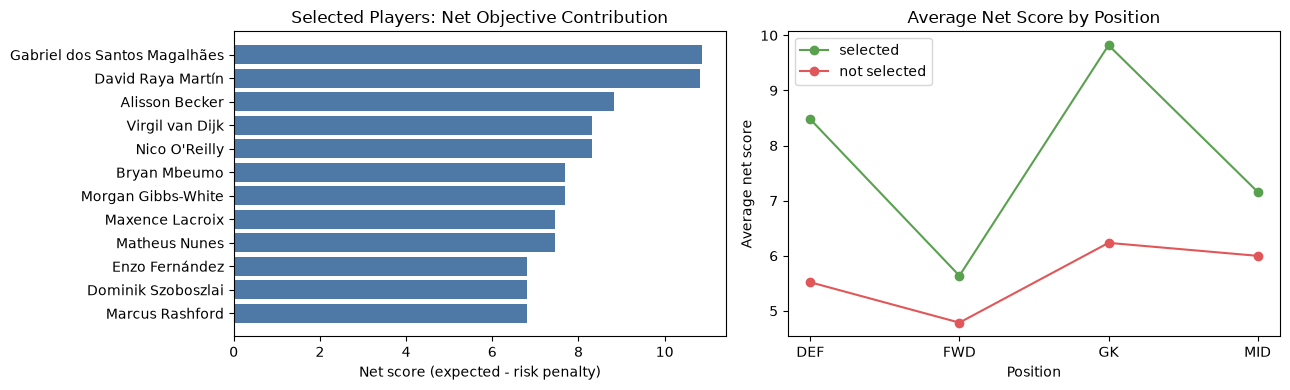

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

top = selected_df.head(12).iloc[::-1]
axes[0].barh(top['player_name'], top['net_score'], color='#4e79a7')
axes[0].set_title('Selected Players: Net Objective Contribution')
axes[0].set_xlabel('Net score (expected - risk penalty)')

pos_comp = score_df.groupby(['position', 'selected'], as_index=False)['net_score'].mean()
for is_sel, color, label in [(True, '#59a14f', 'selected'), (False, '#e15759', 'not selected')]:
    chunk = pos_comp[pos_comp['selected'] == is_sel]
    axes[1].plot(chunk['position'], chunk['net_score'], marker='o', label=label, color=color)
axes[1].set_title('Average Net Score by Position')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Average net score')
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 2: Explain XI, bench, and captain choice
This shows the exact players used in starting XI and bench order from lineup optimization.

In [3]:
selected_pool = [c for c in candidates if c.player_id in selected_ids]
lineup = optimize_lineup(selected_pool, settings=LineupSettings(horizon_index=0), chip_used=squad.chip_used)
by_id = {c.player_id: c for c in selected_pool}

starters = pd.DataFrame([
    {
        'player_name': by_id[pid].player_name,
        'position': by_id[pid].position,
        'team': by_id[pid].team,
        'cost': by_id[pid].cost,
        'expected_w1': by_id[pid].expected_points_horizon[0],
    }
    for pid in lineup.starter_ids
])

bench = pd.DataFrame([
    {
        'bench_slot': i + 1,
        'player_name': by_id[pid].player_name,
        'position': by_id[pid].position,
        'team': by_id[pid].team,
        'expected_w1': by_id[pid].expected_points_horizon[0],
    }
    for i, pid in enumerate(lineup.bench_order_ids)
])

captain = by_id[lineup.captain_id].player_name
vice = by_id[lineup.vice_captain_id].player_name

starters, bench, captain, vice

(                     player_name position team  cost  expected_w1
 0              David Raya Martín       GK  ARS   6.0          4.0
 1   Gabriel dos Santos Magalhães      DEF  ARS   8.0          4.0
 2                Virgil van Dijk      DEF  LIV   6.5          3.1
 3                  Nico O'Reilly      DEF  MCI   6.5          3.1
 4                Maxence Lacroix      DEF  CRY   6.0          2.8
 5                  Matheus Nunes      DEF  MCI   6.0          2.8
 6                   Bryan Mbeumo      MID  MUN   8.0          2.8
 7             Morgan Gibbs-White      MID  NFO   8.0          2.8
 8                 Enzo Fernández      MID  CHE   7.0          2.5
 9             Dominik Szoboszlai      MID  LIV   7.0          2.5
 10               Nicolas Jackson      FWD  CHE   6.5          2.1,
    bench_slot                          player_name position team  expected_w1
 0           1                     Álvaro Rodríguez      FWD  BOU          2.0
 1           2  Francisco Evanilson d

In [5]:
import plotly.express as px

plot_df = pd.DataFrame([
    {
        'player_name': c.player_name,
        'position': c.position,
        'team': c.team,
        'cost': float(c.cost),
        'expected_w1': float(c.expected_points_horizon[0]),
    }
    for c in candidates
]).sort_values(['position', 'expected_w1'], ascending=[True, False]).reset_index(drop=True)

# Add tiny deterministic jitter only for plotting to reduce marker overlap.
rng = np.random.default_rng(42)
plot_df['cost_plot'] = plot_df['cost'] + rng.uniform(-0.02, 0.02, size=len(plot_df))
plot_df['expected_w1_plot'] = plot_df['expected_w1'] + rng.uniform(-0.04, 0.04, size=len(plot_df))

fig = px.scatter(
    plot_df,
    x='cost_plot',
    y='expected_w1_plot',
    color='position',
    symbol='position',
    hover_name='player_name',
    hover_data={
        'team': True,
        'position': True,
        'cost': ':.2f',
        'expected_w1': ':.2f',
        'cost_plot': False,
        'expected_w1_plot': False,
    },
    title='GW1 Candidate Pool: Expected W1 vs Cost (interactive)',
    color_discrete_map={'GK': '#1f77b4', 'DEF': '#2ca02c', 'MID': '#ff7f0e', 'FWD': '#d62728'},
)

fig.update_traces(
    marker=dict(size=11, opacity=0.72, line=dict(width=0.6, color='white')),
    selector=dict(mode='markers'),
)

fig.update_layout(
    width=1000,
    height=1000,
    template='plotly_white',
    xaxis_title='Cost',
    yaxis_title='Expected W1 Points',
    legend_title='Position',
    hovermode='closest',
)

fig.show()

## Step 3: Forecast model feature influence (sample training data)
The live GW1 candidate file uses a proxy expected-points signal.
This section shows feature influence from the forecasting model itself using gradient sensitivity on the project sample dataset.

In [6]:
import torch

from fpl_ai_agent.features.store import build_player_gameweek_features
from fpl_ai_agent.forecasting.trainer import ForecastTrainerConfig, predict_with_uncertainty, train_forecaster

raw = pd.read_csv(ROOT / 'tests' / 'fixtures' / 'raw' / 'fpl_players_sample.csv')
feat = build_player_gameweek_features(raw, window_short=3, window_long=5, min_history=3)

feature_cols = [
    'minutes_prev', 'goals_prev', 'assists_prev', 'ict_prev', 'bps_prev',
    'price_prev', 'fixture_difficulty', 'home_prev', 'form_points_3',
    'form_points_5', 'minutes_rolling_3', 'ict_rolling_3', 'bps_rolling_3',
    'expected_involvement_proxy', 'injury_risk_proxy', 'value_signal',
]

fcfg = ForecastTrainerConfig(
    feature_cols=feature_cols,
    target_col='target_points',
    window_length=3,
    train_seasons={2024},
    valid_seasons=set(),
    test_seasons=set(),
    epochs=6,
    batch_size=8,
    learning_rate=1e-3,
    model_version='explainability_probe_v1',
)
bundle = train_forecaster(feat, fcfg)
windowed, mean_pred, std_pred = predict_with_uncertainty(bundle, feat, target_col='target_points')

len(mean_pred), bundle.metrics

(1, {'valid_mae': 0.0, 'valid_rmse': 0.0, 'test_mae': 0.0, 'test_rmse': 0.0})

In [7]:
if len(mean_pred) == 0:
    raise ValueError('No forecast samples available for explainability.')

sample_idx = int(np.argmax(mean_pred))
x_np = windowed.x[sample_idx:sample_idx+1]
x = torch.tensor(x_np, dtype=torch.float32, requires_grad=True)

bundle.model.eval()
pred_mean, _ = bundle.model(x)
pred_mean.backward()

grads = x.grad.detach().cpu().numpy()[0]
abs_mean_grad = np.abs(grads).mean(axis=0)
importance = pd.Series(abs_mean_grad, index=bundle.feature_cols).sort_values(ascending=False)
importance.head(10)

ict_rolling_3         0.009800
bps_rolling_3         0.008421
injury_risk_proxy     0.008352
form_points_5         0.007926
fixture_difficulty    0.007625
assists_prev          0.006576
ict_prev              0.006461
bps_prev              0.006013
price_prev            0.005787
value_signal          0.004205
dtype: float32

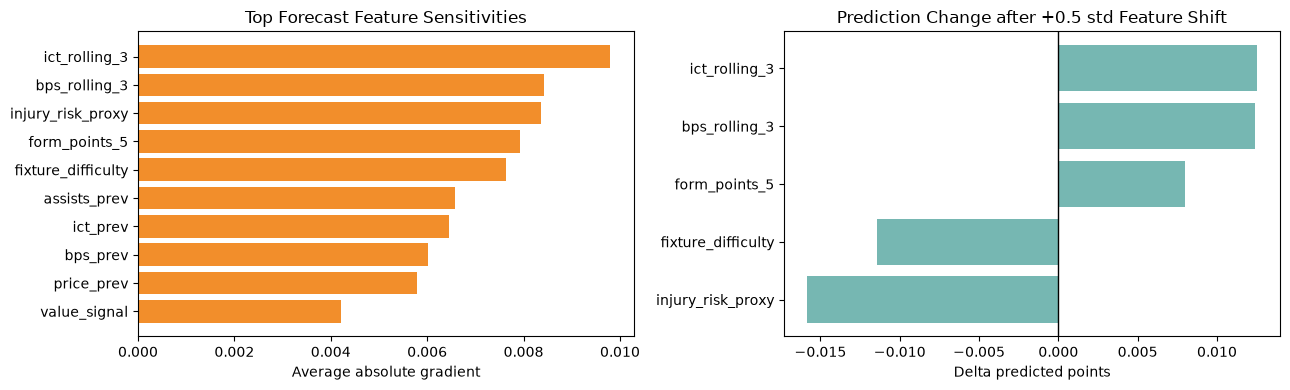

{'sample_index': 0,
 'base_prediction': 0.042,
 'top_features': ['ict_rolling_3',
  'bps_rolling_3',
  'injury_risk_proxy',
  'form_points_5',
  'fixture_difficulty']}

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

top_imp = importance.head(10).iloc[::-1]
axes[0].barh(top_imp.index, top_imp.values, color='#f28e2b')
axes[0].set_title('Top Forecast Feature Sensitivities')
axes[0].set_xlabel('Average absolute gradient')

base_pred = float(mean_pred[sample_idx])
delta_tests = []
for feat_name in importance.head(5).index:
    fi = bundle.feature_cols.index(feat_name)
    x_cf = x_np.copy()
    x_cf[:, :, fi] = x_cf[:, :, fi] + 0.5
    x_t = torch.tensor(x_cf, dtype=torch.float32)
    with torch.no_grad():
        cf_pred, _ = bundle.model(x_t)
    delta_tests.append({'feature': feat_name, 'delta_pred': float(cf_pred.item() - base_pred)})

delta_df = pd.DataFrame(delta_tests).sort_values('delta_pred')
axes[1].barh(delta_df['feature'], delta_df['delta_pred'], color='#76b7b2')
axes[1].axvline(0.0, color='black', linewidth=1)
axes[1].set_title('Prediction Change after +0.5 std Feature Shift')
axes[1].set_xlabel('Delta predicted points')

plt.tight_layout()
plt.show()

{
    'sample_index': sample_idx,
    'base_prediction': round(base_pred, 3),
    'top_features': importance.head(5).index.tolist(),
}

## How to interpret this notebook
1. If a player has high optimizer net score, they are favored for the 15-man squad.
2. Starting XI and captain choices come from a second optimization pass over that squad.
3. Forecast sensitivity plots show which model features most influence predicted points on sample windows.
4. For fully model-based live explainability, connect live GW1 features into the forecasting pipeline instead of proxy expected-points inputs.